## Proximity Learning with CatBoost

This Python code trains a **CatBoost regression model** and computes **instance similarity** based on **proximity learning**. The similarity between two instances is determined by how frequently they appear in the same **leaf node** across trees, with an additional weight based on **tree importance**.

---

## Similarity Computation

We use **Equation (2)** and **Equation (3)** to compute instance similarity.

### Equation (2): Instance Similarity Score

$$
P(i,j) = \frac{1}{N} \sum_{t=1}^{N} \Delta_t \cdot I_t(v(j) = v(i))
$$

where:
- \( N \) is the **total number of trees**.
- \( I_t(v(j) = v(i)) \) is **1 if two instances share a leaf** in tree \( t \), otherwise **0**.
- \( \Delta_t \) is the **importance of tree** \( t \), computed as:

### Equation (3): Tree Importance

$$
\Delta_t = \frac{E(t) - E(t-1)}{\sum_{t=1}^{N} (E(t) - E(t-1))}
$$

where:
- \( E(t) \) is the **error of the model** after tree \( t \).
- The difference \( E(t) - E(t-1) \) measures the **impact of tree \( t \) in reducing error**.

---

## Intuition

- **Instance similarity** is based on **how often instances appear in the same leaf** across trees.
- Trees with **higher importance** (greater error reduction) **contribute more** to the similarity score.
- This approach captures **local relationships** rather than relying on global distance metrics.

This method enhances **interpretability** and **clustering** in machine learning models by leveraging the structure of **gradient boosting decision trees** (GBDTs) like CatBoost.

---

## Step 1: Import Necessary Libraries

In [381]:
import numpy as np
import catboost
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pickle
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.metrics import mean_squared_error, roc_auc_score
from scipy.spatial.distance import pdist, squareform
import numpy as np
import scipy.stats as stats
from scipy.spatial.distance import cdist
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interp1d
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.utils import resample

## Step 2: Loading and Processing Data

In [383]:
import numpy as np
from collections import Counter

# List of datasets
datasets = ["11_donors", "2_annthyroid", "32_shuttle", "33_skin"]

def load_dataset(dataset):
    path = f'/Users/langatkipkemoivincent/Desktop/ssalad/jupyter/data/{dataset}.npz'
    data = np.load(path, allow_pickle=True)
    return data['X'], data['y']

def compute_class_distribution(dataset):
    X, y = load_dataset(dataset)  # Load dataset
    class_counts = Counter(y)  # Count occurrences of each class
    total_instances = len(y)

    # Compute percentage distribution
    class_distribution = {label: (count, count / total_instances * 100) for label, count in class_counts.items()}
    
    # Identify the outlier class (assuming minority class is outlier)
    outlier_label = min(class_distribution, key=lambda k: class_distribution[k][0])
    outlier_percentage = class_distribution[outlier_label][1]

    # Print formatted results
    print(f"\n📊 Class Distribution for {dataset}")
    print("-" * 50)
    for label, (count, percentage) in class_distribution.items():
        print(f"Class {label}: {count} instances ({percentage:.2f}%)")
    print(f"🔹 Outlier Class: {outlier_label} ({outlier_percentage:.2f}% outliers)")

# Loop through datasets and compute class distributions
for dataset in datasets:
    compute_class_distribution(dataset)


📊 Class Distribution for 11_donors
--------------------------------------------------
Class 0: 582616 instances (94.07%)
Class 1: 36710 instances (5.93%)
🔹 Outlier Class: 1 (5.93% outliers)

📊 Class Distribution for 2_annthyroid
--------------------------------------------------
Class 0: 6666 instances (92.58%)
Class 1: 534 instances (7.42%)
🔹 Outlier Class: 1 (7.42% outliers)

📊 Class Distribution for 32_shuttle
--------------------------------------------------
Class 1: 3511 instances (7.15%)
Class 0: 45586 instances (92.85%)
🔹 Outlier Class: 1 (7.15% outliers)

📊 Class Distribution for 33_skin
--------------------------------------------------
Class 1: 50859 instances (20.75%)
Class 0: 194198 instances (79.25%)
🔹 Outlier Class: 1 (20.75% outliers)


# Finance Data

In [596]:
Fdata=pd.read_csv("Variant V.csv")

In [597]:
Fdata.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month,x1,x2
0,0,0.1,0.244166,214,3,50,20.662310,15.930899,AA,1922,...,0,INTERNET,8.513914,linux,1,1,0,0,-0.600198,-0.296015
1,0,0.8,0.035690,-1,242,50,6.134627,20.574086,AA,4614,...,0,INTERNET,4.399087,windows,1,1,0,0,-1.406937,2.136468
2,0,0.9,0.030506,-1,95,50,0.001012,-0.591869,AA,1231,...,0,INTERNET,6.989680,linux,0,1,0,0,-0.688785,0.686640
3,0,0.9,0.840711,-1,105,60,0.012292,106.800603,AA,1874,...,0,INTERNET,50.544274,linux,0,1,0,0,-0.865885,-2.078178
4,0,0.7,0.275118,-1,374,60,1.081235,-0.365989,AD,5070,...,0,INTERNET,4.847442,linux,1,1,0,0,-0.339504,-2.032053


In [598]:
Fdata.describe()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,...,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month,x1,x2
count,1000000.000000,1000000.000000,1.000000e+06,1000000.000000,1000000.000000,1000000.00000,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.0,1000000.000000,1000000.000000,1000000.000000
mean,0.011030,0.578958,4.875269e-01,14.744036,99.187295,41.34948,9.164764e-01,8.571482,1517.471615,5490.939853,...,0.248917,551.037350,0.023991,7.817692,0.556301,1.022276,0.0,3.658708,0.010499,0.008503
std,0.104443,0.288226,2.913674e-01,43.134138,94.070293,13.75192,5.068976e+00,20.544640,965.945989,2940.124992,...,0.432386,506.530093,0.153021,8.259055,0.496820,0.192862,0.0,2.116726,1.010044,1.009068
min,0.000000,0.100000,7.898994e-07,-1.000000,-1.000000,10.00000,1.414624e-07,-15.710457,1.000000,-143.649721,...,0.000000,190.000000,0.000000,-1.000000,0.000000,-1.000000,0.0,0.000000,-4.977864,-4.846414
25%,0.000000,0.300000,2.145294e-01,-1.000000,27.000000,30.00000,7.451458e-03,-1.178938,885.000000,3332.981127,...,0.000000,200.000000,0.000000,3.151601,0.000000,1.000000,0.0,2.000000,-0.669626,-0.670979
50%,0.000000,0.600000,4.858928e-01,-1.000000,64.000000,50.00000,1.567347e-02,-0.833821,1208.000000,5190.722819,...,0.000000,200.000000,0.000000,5.246432,1.000000,1.000000,0.0,4.000000,0.005114,0.003902
75%,0.000000,0.800000,7.545309e-01,-1.000000,154.000000,50.00000,2.698820e-02,-0.052483,1846.000000,7371.559084,...,0.000000,1000.000000,0.000000,9.362126,1.000000,1.000000,0.0,5.000000,0.683212,0.680875
max,1.000000,0.900000,9.999997e-01,384.000000,426.000000,90.00000,7.784555e+01,113.086228,6830.000000,16802.052304,...,1.000000,2100.000000,1.000000,83.213536,1.000000,2.000000,0.0,7.000000,6.434867,6.542492


In [599]:
y1=Fdata['fraud_bool']
X1=Fdata.drop('fraud_bool',axis=1)
X1, y1 = limit_dataset(X1, y1, max_samples=20000)
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, stratify=y1, random_state=42)

In [389]:
from flaml import AutoML
automl = AutoML()
estimator_list = ["catboost"]
automl_settings = {
    "time_budget": 20,  # total running time in seconds
    "task": 'classification',  # task type
    "seed": 24545678,  # random seed
    "metric":  "roc_auc",  # evaluation metric
    "estimator_list": estimator_list,  # specify the list of estimators
}
automl.fit(X_train=X_train, y_train=y_train, **automl_settings)

[flaml.automl.logger: 02-28 02:20:33] {1728} INFO - task = classification
[flaml.automl.logger: 02-28 02:20:33] {1739} INFO - Evaluation method: holdout
[flaml.automl.logger: 02-28 02:20:33] {1838} INFO - Minimizing error metric: 1-roc_auc
[flaml.automl.logger: 02-28 02:20:33] {1955} INFO - List of ML learners in AutoML Run: ['catboost']
[flaml.automl.logger: 02-28 02:20:33] {2258} INFO - iteration 0, current learner catboost
[flaml.automl.logger: 02-28 02:20:36] {2393} INFO - Estimated sufficient time budget=20748s. Estimated necessary time budget=21s.
[flaml.automl.logger: 02-28 02:20:36] {2442} INFO -  at 2.3s,	estimator catboost's best error=0.0999,	best estimator catboost's best error=0.0999
[flaml.automl.logger: 02-28 02:20:36] {2258} INFO - iteration 1, current learner catboost
[flaml.automl.logger: 02-28 02:20:39] {2442} INFO -  at 6.0s,	estimator catboost's best error=0.0948,	best estimator catboost's best error=0.0948
[flaml.automl.logger: 02-28 02:20:39] {2258} INFO - iterat

In [390]:
# Predict probabilities for the test set
y_pred_prob = automl.predict_proba(X_test)[:, 1]  # Get probability for class 1

# Compute AUC
auc_score = roc_auc_score(y_test, y_pred_prob)
#print(f"Best Model: {automl.best_estimator}")
print(f"AUC Score on Test Data: {auc_score:.4f}")

AUC Score on Test Data: 0.8809


In [391]:
import numpy as np

def cap_values(matrix, lower_percentile=5, upper_percentile=95):
    lower_bound = np.percentile(matrix, lower_percentile)
    upper_bound = np.percentile(matrix, upper_percentile)
    
    # Clip values within the computed bounds
    capped_matrix = np.clip(matrix, lower_bound, upper_bound)
    
    return capped_matrix


## Step 3: Defining Function to Train CatBoost and Compute Similarity

In [393]:

def ensure_dataframe(X):
    """Ensures X is a Pandas DataFrame."""
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
    return X

def detect_categorical_columns(X):
    """Detects categorical columns in X."""
    if isinstance(X, pd.DataFrame):
        return X.select_dtypes(include=['object', 'category']).columns.tolist()
    return []

def cap_values(matrix):
    """Ensures matrix values are within [0,1] range."""
    return np.clip(matrix, 0, 1)

def limit_dataset(X, y, max_samples=20000):
    """Stratifies and limits X to max_samples while preserving class distribution."""
    if len(X) > max_samples:
        X, y = resample(X, y, replace=False, stratify=y, n_samples=max_samples, random_state=42)
    return X, y

def compute_similarity(X, y, active_learning_fraction=0.5):
    # Ensure X is a DataFrame
    X = ensure_dataframe(X)
    
    # Ensure y is a 1D array
    y = np.ravel(y) if isinstance(y, np.ndarray) else y
    
    # Limit X to max 20,000 observations
    X, y = limit_dataset(X, y, max_samples=100000)
    
    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    n_labeled = int(active_learning_fraction * len(X_train))
    
    # Detect and drop categorical columns
    categorical_columns = detect_categorical_columns(X_train)
    if categorical_columns:
        X_train = X_train.drop(columns=categorical_columns)

    # Ensure at least one numerical column remains
    if X_train.shape[1] == 0:
        raise ValueError("No numerical features available for clustering.")

    # KMeans clustering (limited to max 1000 clusters)
    n_clusters = min(n_labeled, 1000)
    clustering = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = clustering.fit_predict(X_train)

    # Select representative points
    selected_indices = [np.where(cluster_labels == c)[0][0] for c in np.unique(cluster_labels)]
    X_labeled, y_labeled = X_train.iloc[selected_indices], y_train.iloc[selected_indices]
    X_unlabeled, y_unlabeled = X_train.drop(index=X_train.index[selected_indices]), y_train.drop(index=y_train.index[selected_indices])

    # Train CatBoost CLASSIFIER
    model = CatBoostClassifier(iterations=50, learning_rate=0.1, depth=6, verbose=0, eval_metric="AUC")
    model.fit(X_labeled, y_labeled)

    # Predict for UNLABELED data
    y_unlabeled_pred = model.predict_proba(X_unlabeled)[:, 1]  # Get probability for class 1

    # Compute AUC Score for `y_unlabeled`
    auc_score_unlabeled = roc_auc_score(y_unlabeled, y_unlabeled_pred)
    print(f"AUC Score : {auc_score_unlabeled:.4f}")

    # Expand labeled dataset
    X_labeled = pd.concat([X_labeled, X_unlabeled])
    y_labeled = np.hstack((y_labeled, y_unlabeled_pred))

    # Compute tree-based similarity
    leaf_indices_train = model.calc_leaf_indexes(X_labeled)

    # Compute similarity matrix
    num_trees = model.tree_count_
    similarity_matrix = np.zeros((len(X_labeled), len(X_labeled)))

    for t in range(num_trees):
        leaf_assignments = leaf_indices_train[:, t]
        mask = leaf_assignments[:, None] == leaf_assignments[None, :]
        similarity_matrix += mask

    similarity_matrix /= num_trees
    similarity_matrix = cap_values(MinMaxScaler().fit_transform(similarity_matrix))

    # Select inliers and outliers
    np.random.seed(42)
    inlier_indices_all = np.where(y_labeled == 0)[0]
    outlier_indices_all = np.where(y_labeled == 1)[0]
    
    inlier_indices = np.random.choice(inlier_indices_all, min(20, len(inlier_indices_all)), replace=False)
    outlier_indices = np.random.choice(outlier_indices_all, min(10, len(outlier_indices_all)), replace=False)
    
    selected_indices = np.concatenate([inlier_indices, outlier_indices])

    # Extract the 30x30 similarity sub-matrix
    similarity_matrix = similarity_matrix[selected_indices][:, selected_indices]
    similarity_matrix = cap_values(similarity_matrix)

    # Compute Euclidean distance matrix
    distance_matrix = cdist(X_labeled.iloc[selected_indices], X_labeled.iloc[selected_indices], metric='euclidean')
    distance_matrix = cap_values(MinMaxScaler().fit_transform(distance_matrix))

    return similarity_matrix, distance_matrix, model


In [436]:
def compute_similarity2(X, y, active_learning_fraction=0.2, query_strategy='clusters'):
    # Stratified split for class balance
     # Limit X to max 20,000 observations
    X, y = limit_dataset(X, y, max_samples=100000)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    n_labeled = int(active_learning_fraction * len(X_train))
    
    # Ensure label diversity
    unique_labels = np.unique(y_train)
    if len(unique_labels) == 1:
        raise ValueError("Training set has only one unique target value. Adjust sampling method.")
    
    # Active Learning: Clustering strategy
    kmeans = KMeans(n_clusters=n_labeled, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_train)
    
    # Select representative points
    selected_indices = []
    for cluster in np.unique(cluster_labels):
        cluster_indices = np.where(cluster_labels == cluster)[0]
        selected_indices.append(cluster_indices[0])  # Pick first point in each cluster
    
    X_labeled, y_labeled = X_train[selected_indices], y_train[selected_indices]
    X_unlabeled, y_unlabeled = np.delete(X_train, selected_indices, axis=0), np.delete(y_train, selected_indices, axis=0)
    
    # Train CatBoost model
    model = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0)
    model.fit(X_labeled, y_labeled)
    
    # Predict labels for the unlabeled dataset
    y_unlabeled_pred = model.predict(X_unlabeled)
    
    # Expand labeled dataset
    X_labeled = np.vstack((X_labeled, X_unlabeled))
    y_labeled = np.hstack((y_labeled, y_unlabeled_pred))
    
    # Evaluate model performance
    if len(np.unique(y_unlabeled_pred)) > 1:
        auc_score = roc_auc_score(y_unlabeled, y_unlabeled_pred)
        print(f"Model AUC Score: {auc_score:.4f}")
    else:
        print("Skipping AUC calculation: y_test contains only one class.")
    
    # Compute tree-based similarity
    leaf_indices_train = model.calc_leaf_indexes(X_labeled)
    preds = model.predict(X_labeled)
    errors = np.square(preds - y_labeled)

    tree_errors = [
        mean_squared_error(y_labeled, np.array(list(model.staged_predict(X_labeled, ntree_end=i))[-1]))
        for i in range(1, model.tree_count_ + 1)
    ]
    
    tree_errors = np.array(tree_errors)
    
    # Compute tree importance
    delta_t = np.diff(tree_errors, prepend=0)
    delta_t = np.abs(delta_t)
    delta_t /= np.sum(delta_t)
    
    # Compute similarity matrix
    num_trees = model.tree_count_
    similarity_matrix = np.zeros((len(X_labeled), len(X_labeled)))
    
    for t in range(num_trees):
        leaf_assignments = leaf_indices_train[:, t]
        for i in range(len(X_labeled)):
            for j in range(len(X_labeled)):
                if leaf_assignments[i] == leaf_assignments[j]:
                    similarity_matrix[i, j] += delta_t[t]
    
    similarity_matrix /= num_trees
    
    # Normalize similarity values
    scaler = MinMaxScaler()
    similarity_matrix = scaler.fit_transform(similarity_matrix)
    similarity_matrix=cap_values(similarity_matrix)

    # Select random inliers and outliers
    np.random.seed(42)
    inlier_indices_all = np.where(y_labeled == 0)[0]  
    outlier_indices_all = np.where(y_labeled == 1)[0]  
    inlier_indices = np.random.choice(inlier_indices_all, 20, replace=False)
    outlier_indices = np.random.choice(outlier_indices_all, 10, replace=False)
    selected_indices = np.concatenate([inlier_indices, outlier_indices])

    # Extract the 30x30 similarity sub-matrix
    similarity_matrix = similarity_matrix[selected_indices][:, selected_indices]
    similarity_matrix=cap_values(similarity_matrix)

    # Compute Euclidean distance matrix
    distance_matrix = cdist(X_labeled[selected_indices], X_labeled[selected_indices], metric='euclidean')
    distance_matrix=cap_values(distance_matrix)

    # Normalize distance matrix to [0,1]
    scaler = MinMaxScaler()
    distance_matrix = scaler.fit_transform(distance_matrix)
    distance_matrix=cap_values(distance_matrix)
    
    return similarity_matrix, distance_matrix, model


## Step 4: Training Model and Computing Similarity for Each Dataset

In [438]:
results = {}

In [439]:
# Load dataset
print(f'Processing Bank_fraud...')
X, y = X1,y1
sample_size = min(30000, len(X))
indices = np.random.choice(len(X), sample_size, replace=True)
X_sample, y_sample = X.iloc[indices], y.iloc[indices]
similarity_matrix, distance_matrix, model = compute_similarity(X_sample, y_sample)
results['Bank_fraud'] = {
        'similarity_matrix': similarity_matrix,
        'distance_matrix': distance_matrix,
        'model': model
    }
for dataset in datasets:
    print(f'Processing {dataset}...')
    
    # Load dataset
    X, y = load_dataset(dataset)
    sample_size = min(3000, len(X))
    indices = np.random.choice(len(X), sample_size, replace=False)
    X_sample, y_sample = X[indices], y[indices]
    similarity_matrix, distance_matrix, model = compute_similarity2(X_sample, y_sample)
    results[dataset] = {
        'similarity_matrix': similarity_matrix,
        'distance_matrix': distance_matrix,
        'model': model
    }
print("Processing complete for all datasets!")

Processing Bank_fraud...
AUC Score (Unlabeled Data): 0.7194
Processing 11_donors...
Model AUC Score: 1.0000
Processing 22_magic.gamma...
Model AUC Score: 0.8642
Processing 24_mnist...
Model AUC Score: 0.9926
Processing 27_PageBlocks...
Model AUC Score: 0.9805
Processing 2_annthyroid...
Model AUC Score: 0.9930
Processing 30_satellite...
Model AUC Score: 0.9359
Processing 32_shuttle...
Model AUC Score: 1.0000
Processing 33_skin...
Model AUC Score: 1.0000
Processing 6_cardio...
Model AUC Score: 0.9985
Processing 7_Cardiotocography...
Model AUC Score: 0.9782
Processing complete for all datasets!


## Step 5:Visualizing similarty and distance Values

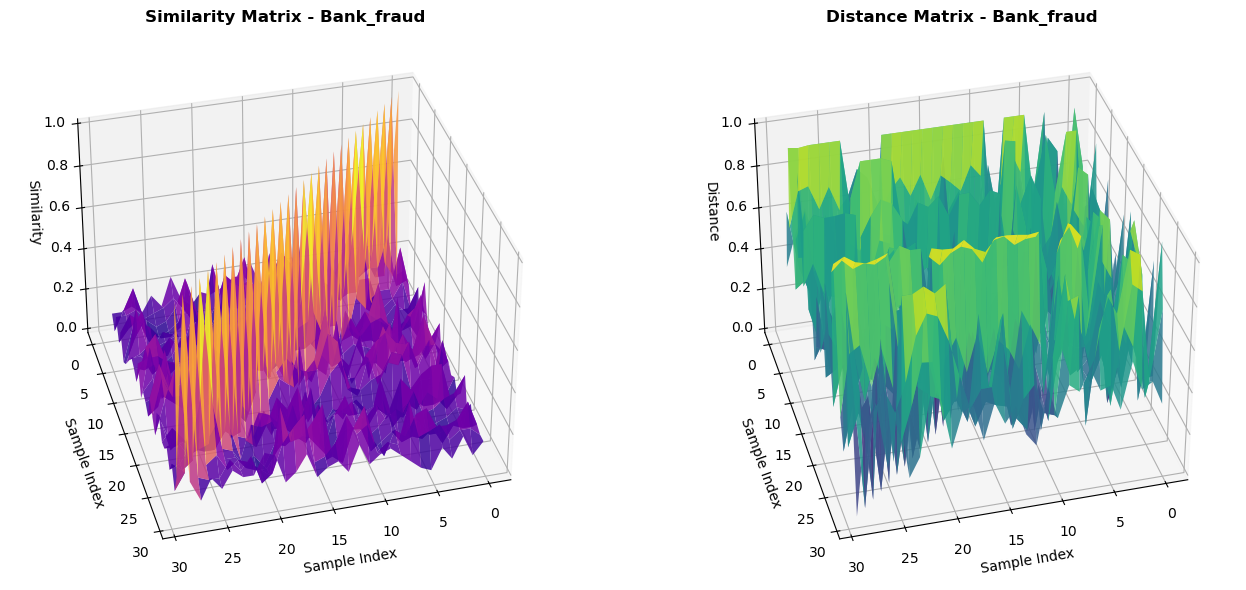

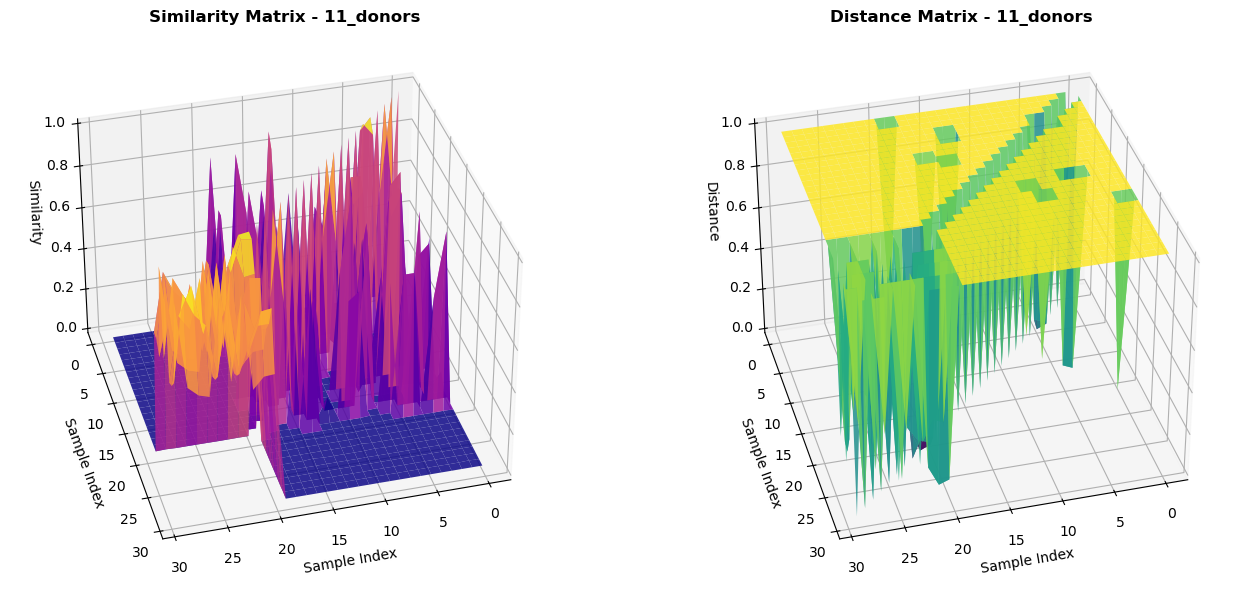

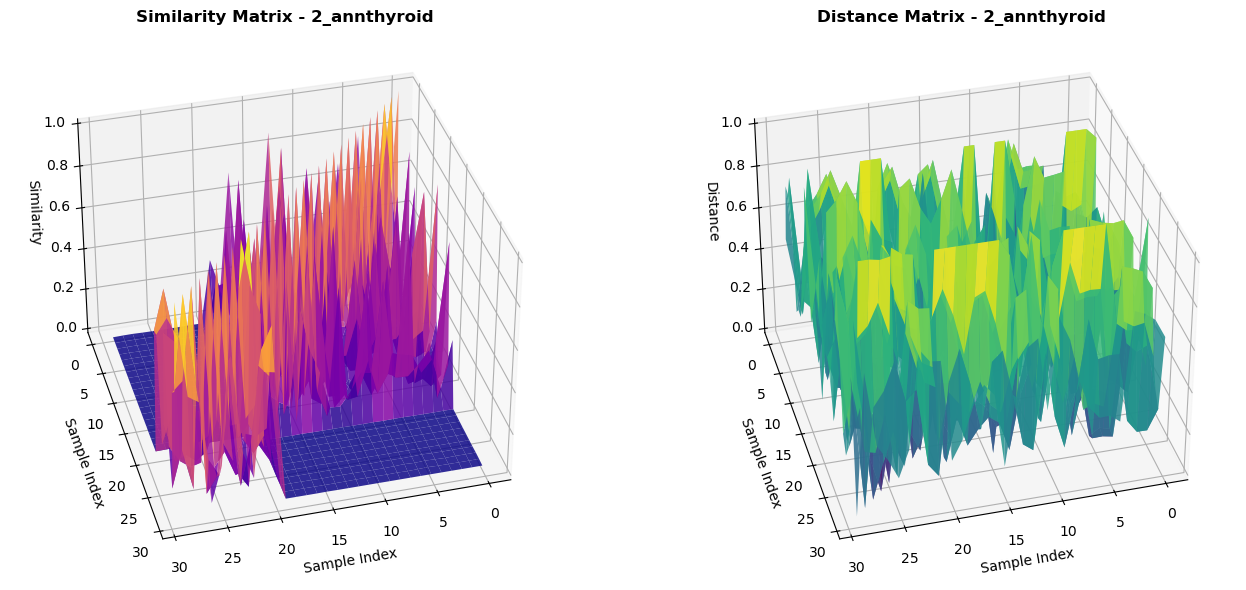

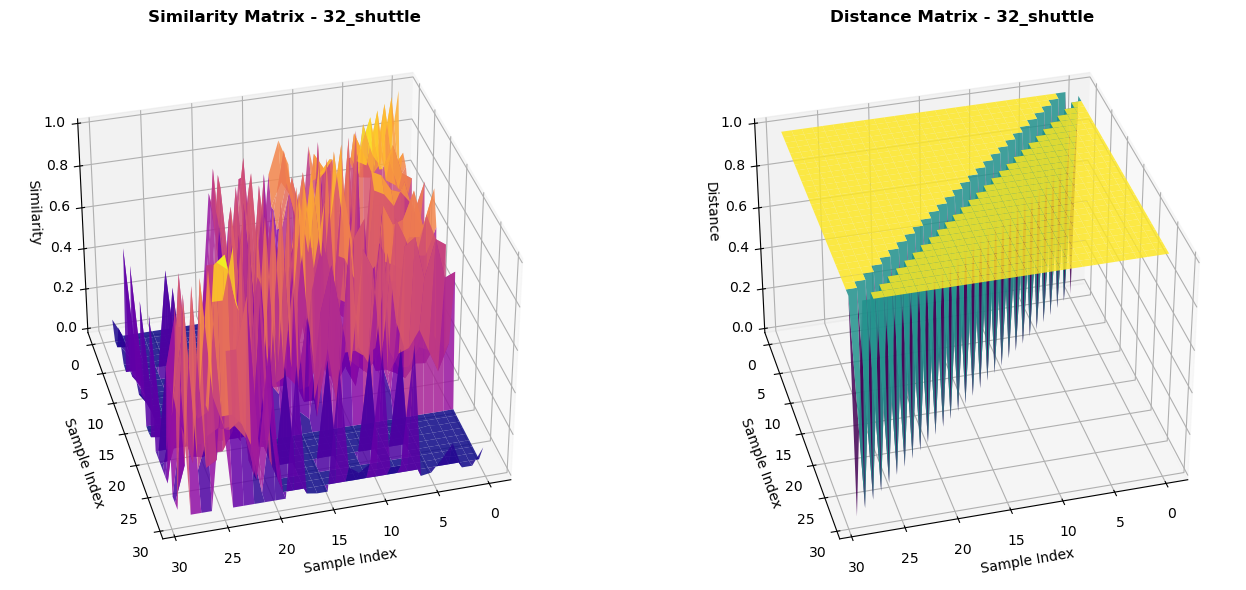

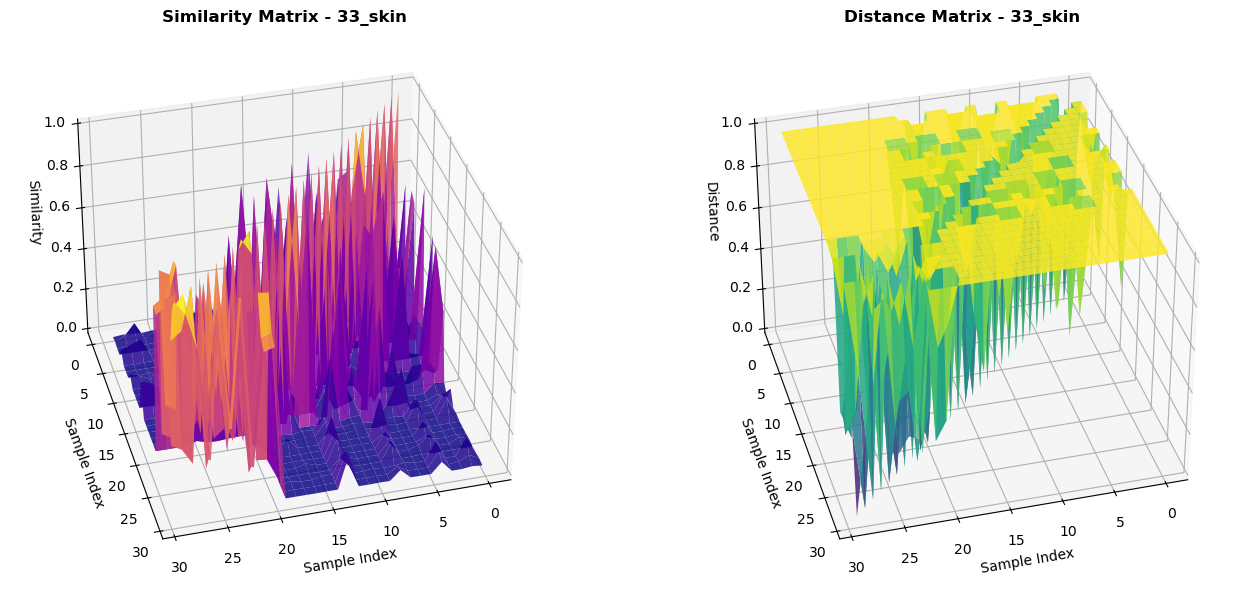

In [442]:
def generate_3d_surface(matrix, title, xlabel, ylabel, zlabel, filename):
    X = np.arange(matrix.shape[1])
    Y = np.arange(matrix.shape[0])
    X, Y = np.meshgrid(X, Y)
    Z = matrix
    
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.85)
    ax.set_xlabel(xlabel, fontsize=10, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10, fontweight='bold')
    ax.set_zlabel(zlabel, fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.view_init(elev=30, azim=120)
    cbar = fig.colorbar(surf, shrink=0.5, aspect=7)
    cbar.set_label('Magnitude', fontsize=10)
    plt.savefig(filename, format='pdf', bbox_inches='tight')
    plt.tight_layout()
    plt.show()

datasets = ["Bank_fraud","11_donors", "2_annthyroid", "32_shuttle", "33_skin"]

for dataset_name in datasets:
    if dataset_name in results:
        similarity_matrix = results[dataset_name]['similarity_matrix']
        distance_matrix = results[dataset_name]['distance_matrix']
    else:
        print(f"Warning: No precomputed results found for {dataset_name}")
        continue
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': '3d'})
    
    X_grid, Y_grid = np.meshgrid(np.arange(similarity_matrix.shape[1]), np.arange(similarity_matrix.shape[0]))
    
    axes[0].plot_surface(X_grid, Y_grid, similarity_matrix, cmap='plasma', edgecolor='none', alpha=0.85)
    axes[0].set_title(f'Similarity Matrix - {dataset_name}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Sample Index')
    axes[0].set_ylabel('Sample Index')
    axes[0].set_zlabel('Similarity')
    axes[0].view_init(elev=35, azim=75)
    
    axes[1].plot_surface(X_grid, Y_grid, distance_matrix, cmap='viridis', edgecolor='none', alpha=0.85)
    axes[1].set_title(f'Distance Matrix - {dataset_name}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Sample Index')
    axes[1].set_ylabel('Sample Index')
    axes[1].set_zlabel('Distance')
    axes[1].view_init(elev=35, azim=75)
    plt.tight_layout()
    plt.savefig(f"{dataset_name}_similarity_distance_matrices.pdf", format='pdf', bbox_inches='tight')
    plt.show()

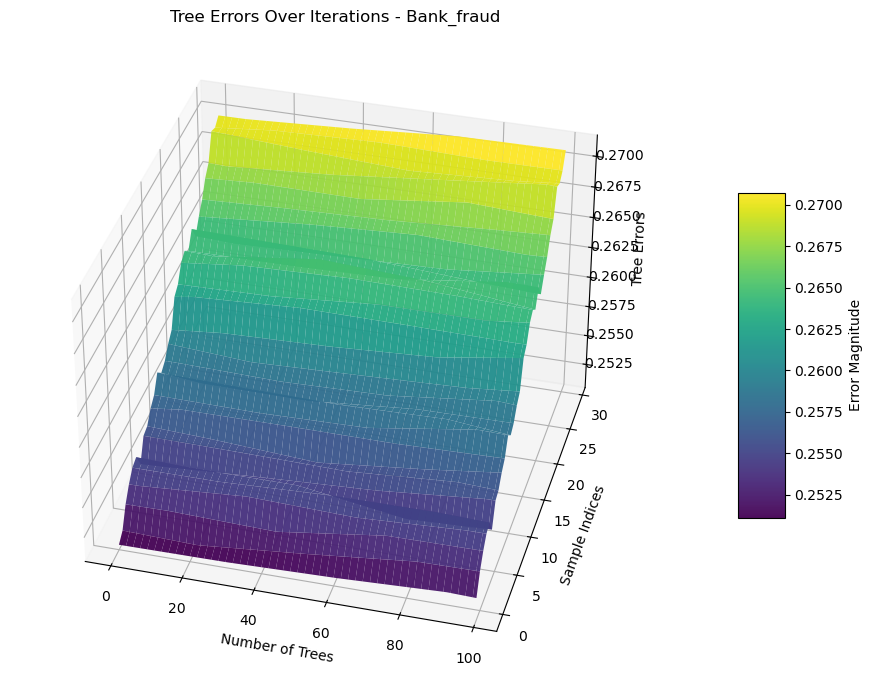

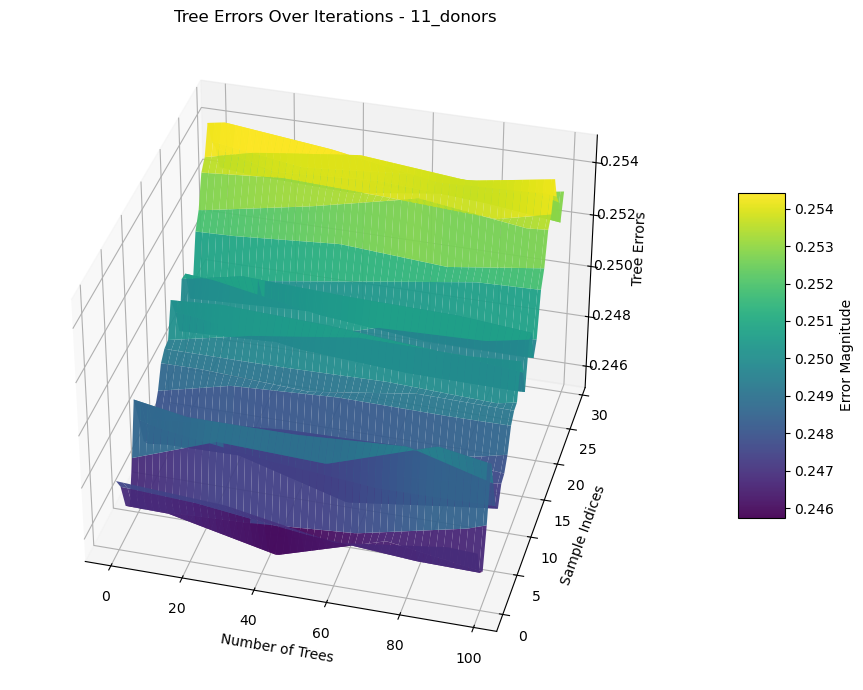

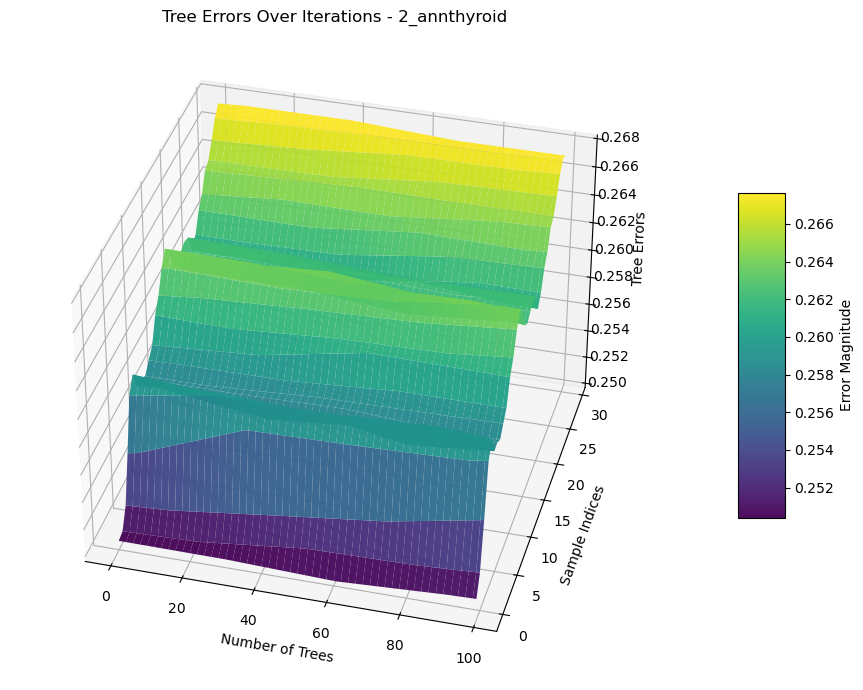

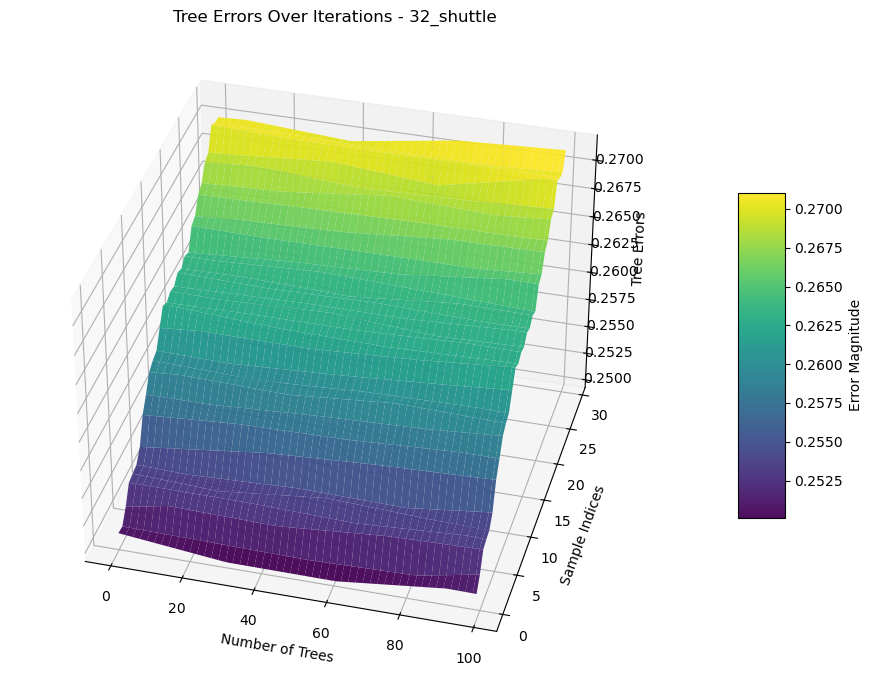

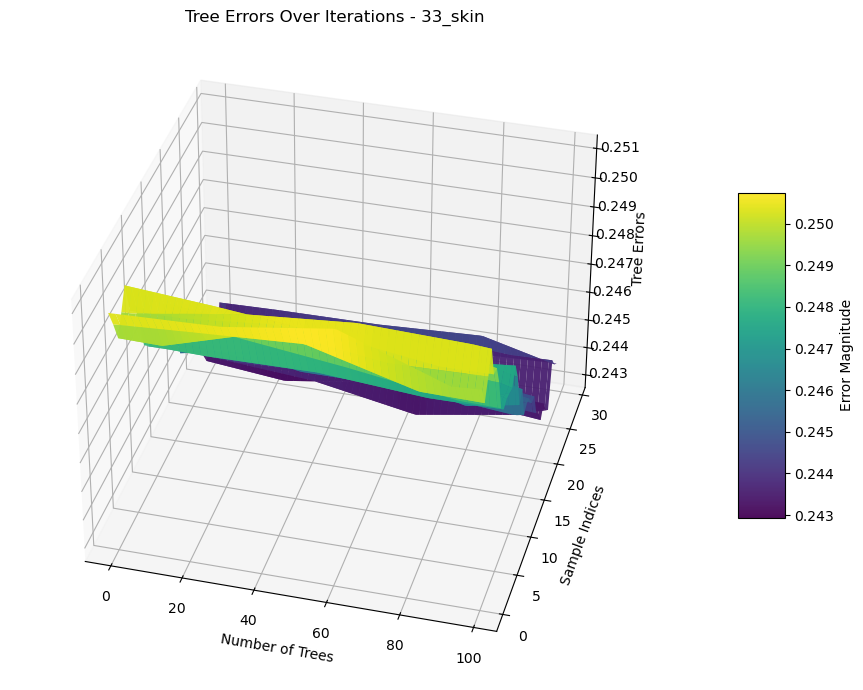

In [443]:
def generate_tree_error_plot(tree_errors, dataset_name):
    tree_count = tree_errors.shape[1]
    sample_count = tree_errors.shape[0]
    
    # Generate grid for plotting
    tree_indices = np.arange(tree_count)
    sample_indices = np.arange(sample_count)
    X, Y = np.meshgrid(tree_indices, sample_indices)
    Z = tree_errors  # Use provided tree errors
    
    # Create figure
    fig = plt.figure(figsize=(16, 7))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot surface with improved customization
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.95)
    ax.set_xlabel('Number of Trees', fontsize=10)
    ax.set_ylabel('Sample Indices', fontsize=10, )
    ax.set_zlabel('Tree Errors', fontsize=10)
    ax.set_title(f'Tree Errors Over Iterations - {dataset_name}', fontsize=12)
    ax.grid(True, linestyle='--', linewidth=0.3)
    ax.view_init(elev=35, azim=-75)  # Adjust view angle for better visibility
    
    # Add color bar
    cbar = fig.colorbar(surf, shrink=0.5, aspect=7)
    cbar.set_label('Error Magnitude', fontsize=10)
    
    # Save figure as PDF
    pdf_filename = f"{dataset_name}_tree_errors.pdf"
    plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
    
    plt.tight_layout()
    plt.show()

# Dataset names
datasets =["Bank_fraud","11_donors", "2_annthyroid", "32_shuttle", "33_skin"]

def compute_tree_errors(dataset_name):
    # Load dataset (replace with actual data loading mechanism)
    np.random.seed(hash(dataset_name) % 1000)  # Different seed per dataset
    X = np.random.rand(1000, 20)  # Example feature set
    y = np.random.randint(0, 2, 1000)  # Example binary labels
    
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Train CatBoost model
    model = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0)
    model.fit(X_train, y_train)
    
    # Compute tree errors over iterations
    tree_errors = np.array([
        mean_squared_error(y_test, np.array(list(model.staged_predict(X_test, ntree_end=i))[-1]))
        for i in range(1, model.tree_count_ + 1)
    ])
    
    # Interpolate to match desired shape (30, 100)
    x_original = np.linspace(0, 1, len(tree_errors))
    x_new = np.linspace(0, 1, 30 * 100)
    interpolator = interp1d(x_original, tree_errors, kind='linear', fill_value='extrapolate')
    tree_errors_resampled = interpolator(x_new).reshape(30, 100)
    
    return tree_errors_resampled  # Reshape for plotting

# Loop through datasets and generate plots
for dataset_name in datasets:
    tree_errors = compute_tree_errors(dataset_name)
    generate_tree_error_plot(tree_errors, dataset_name)

## Step 6: Plotting Similarity and distance Heatmaps

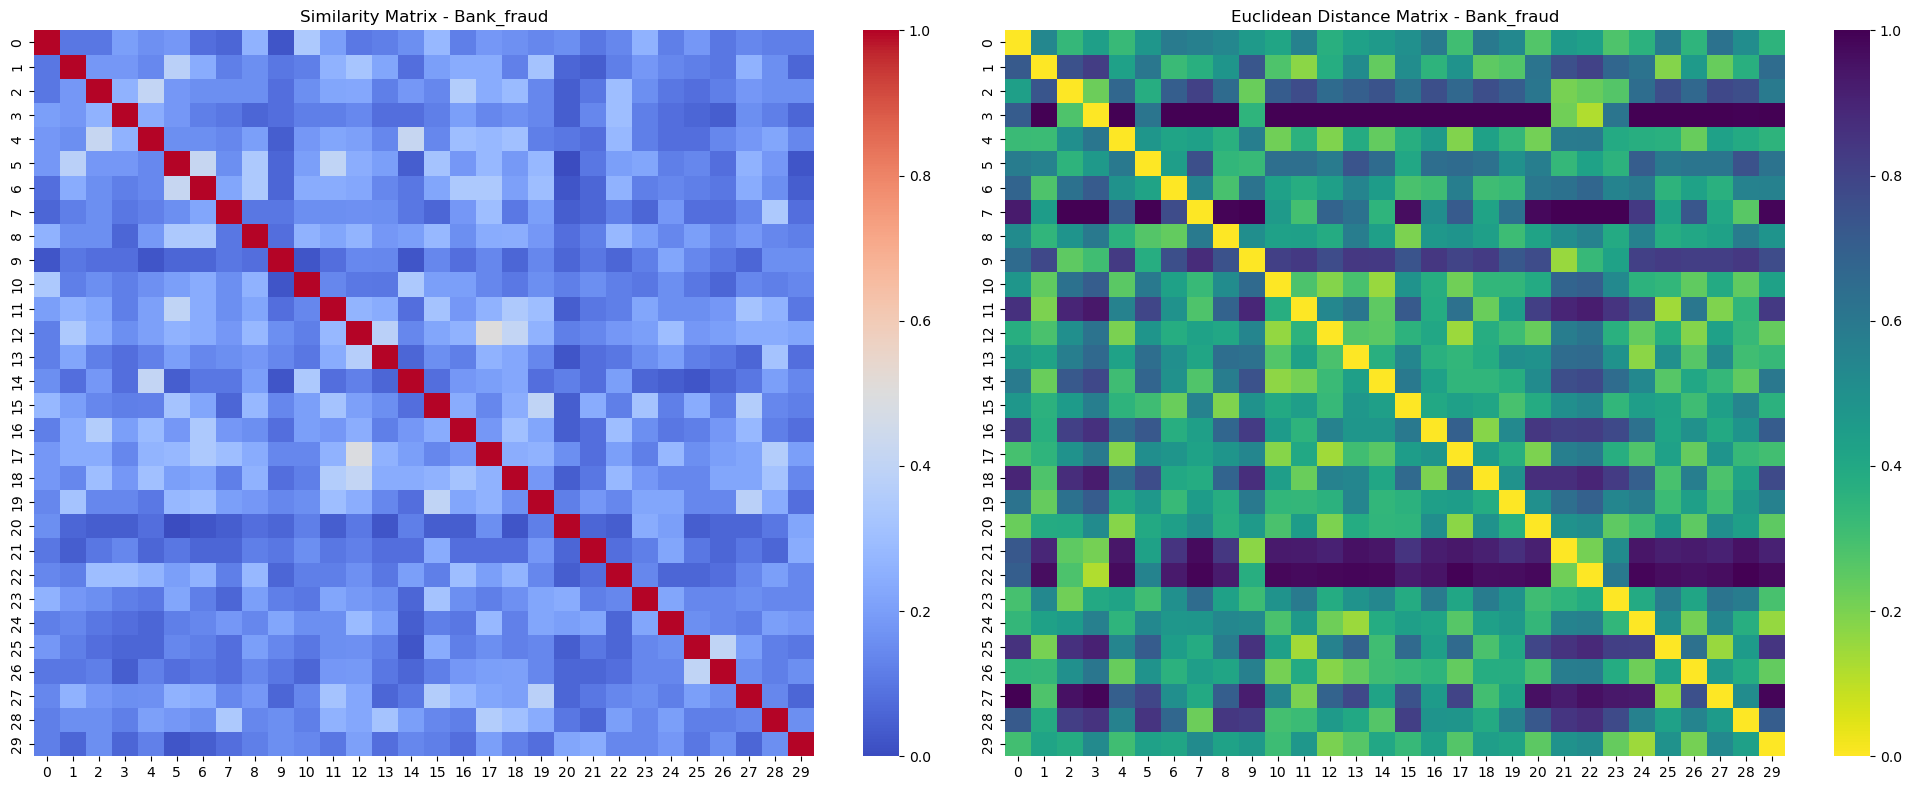

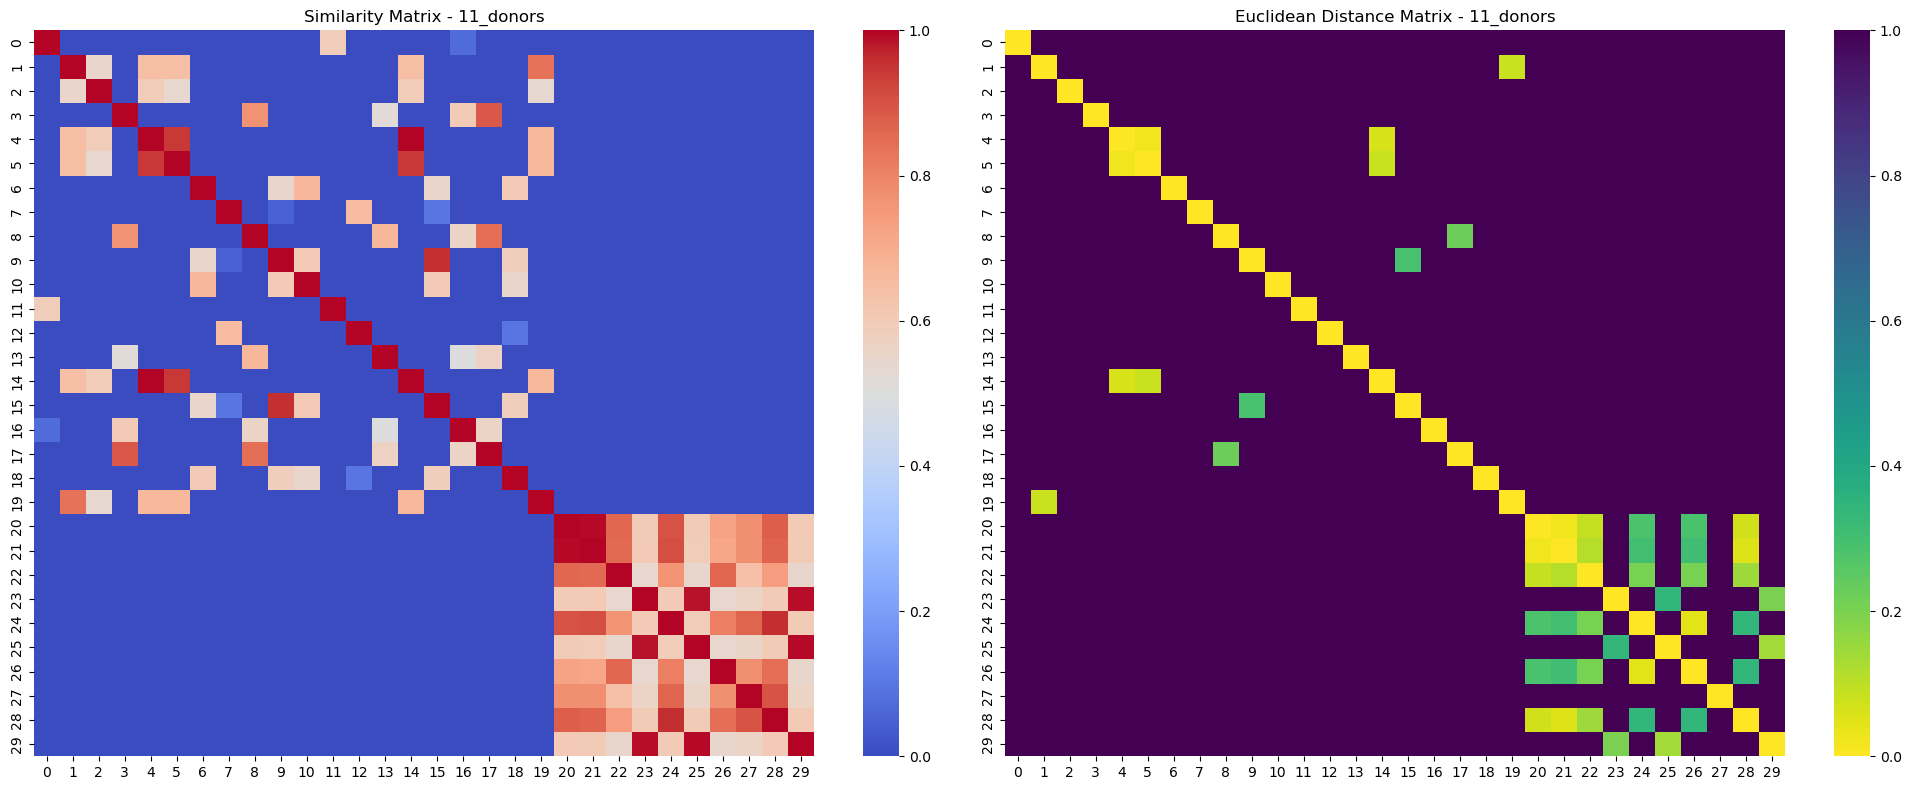

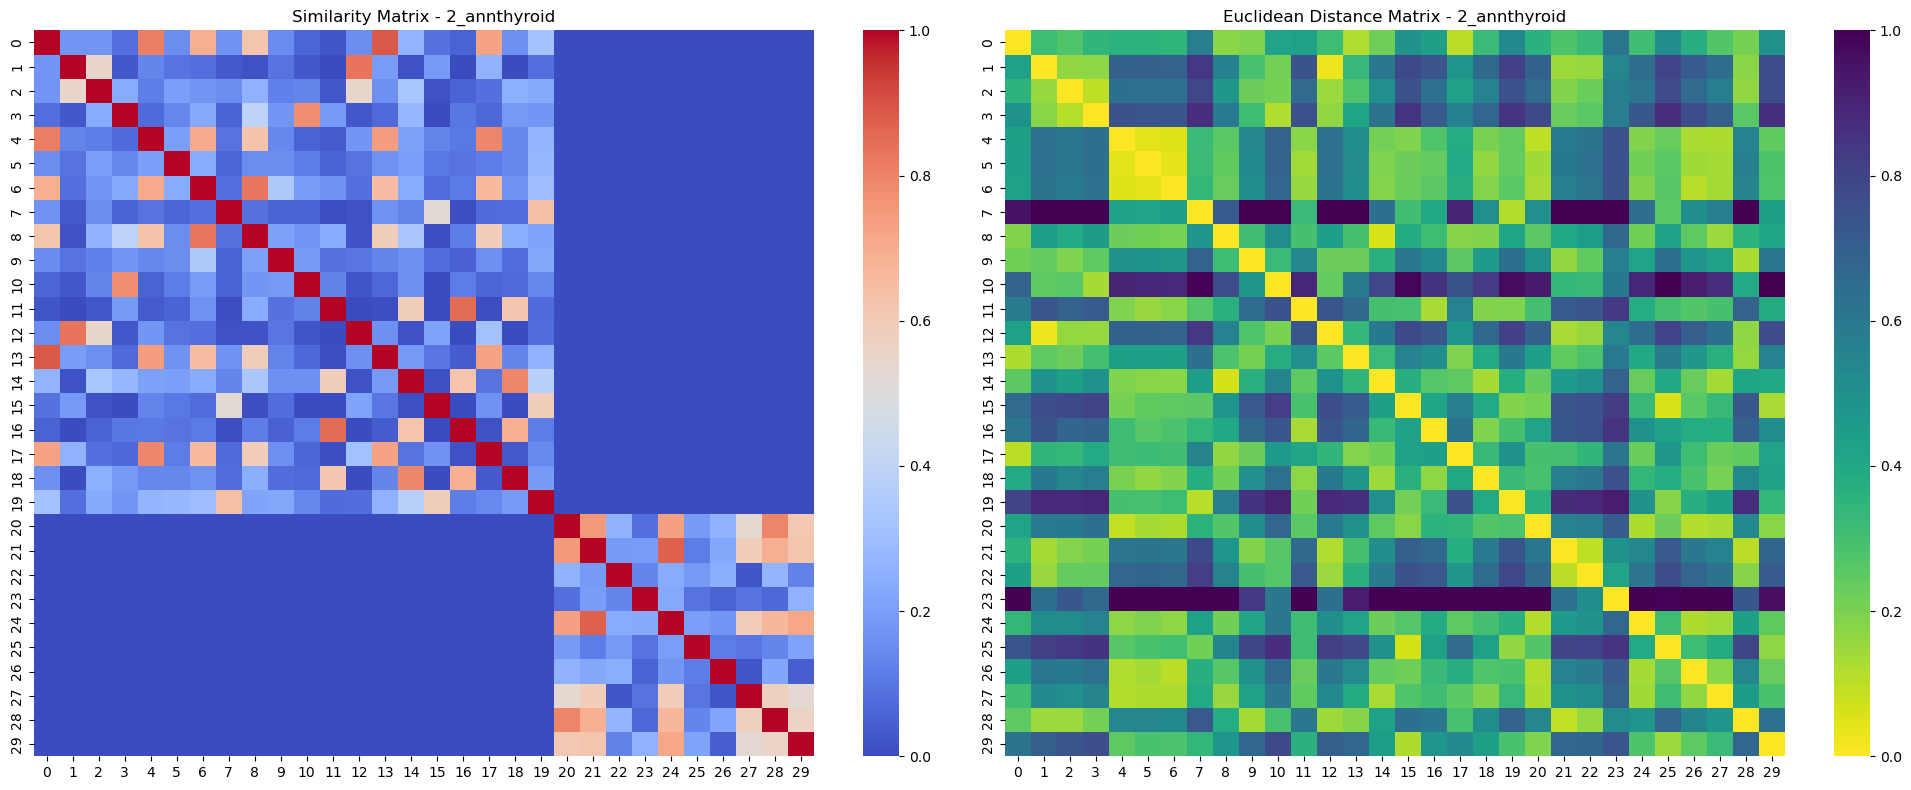

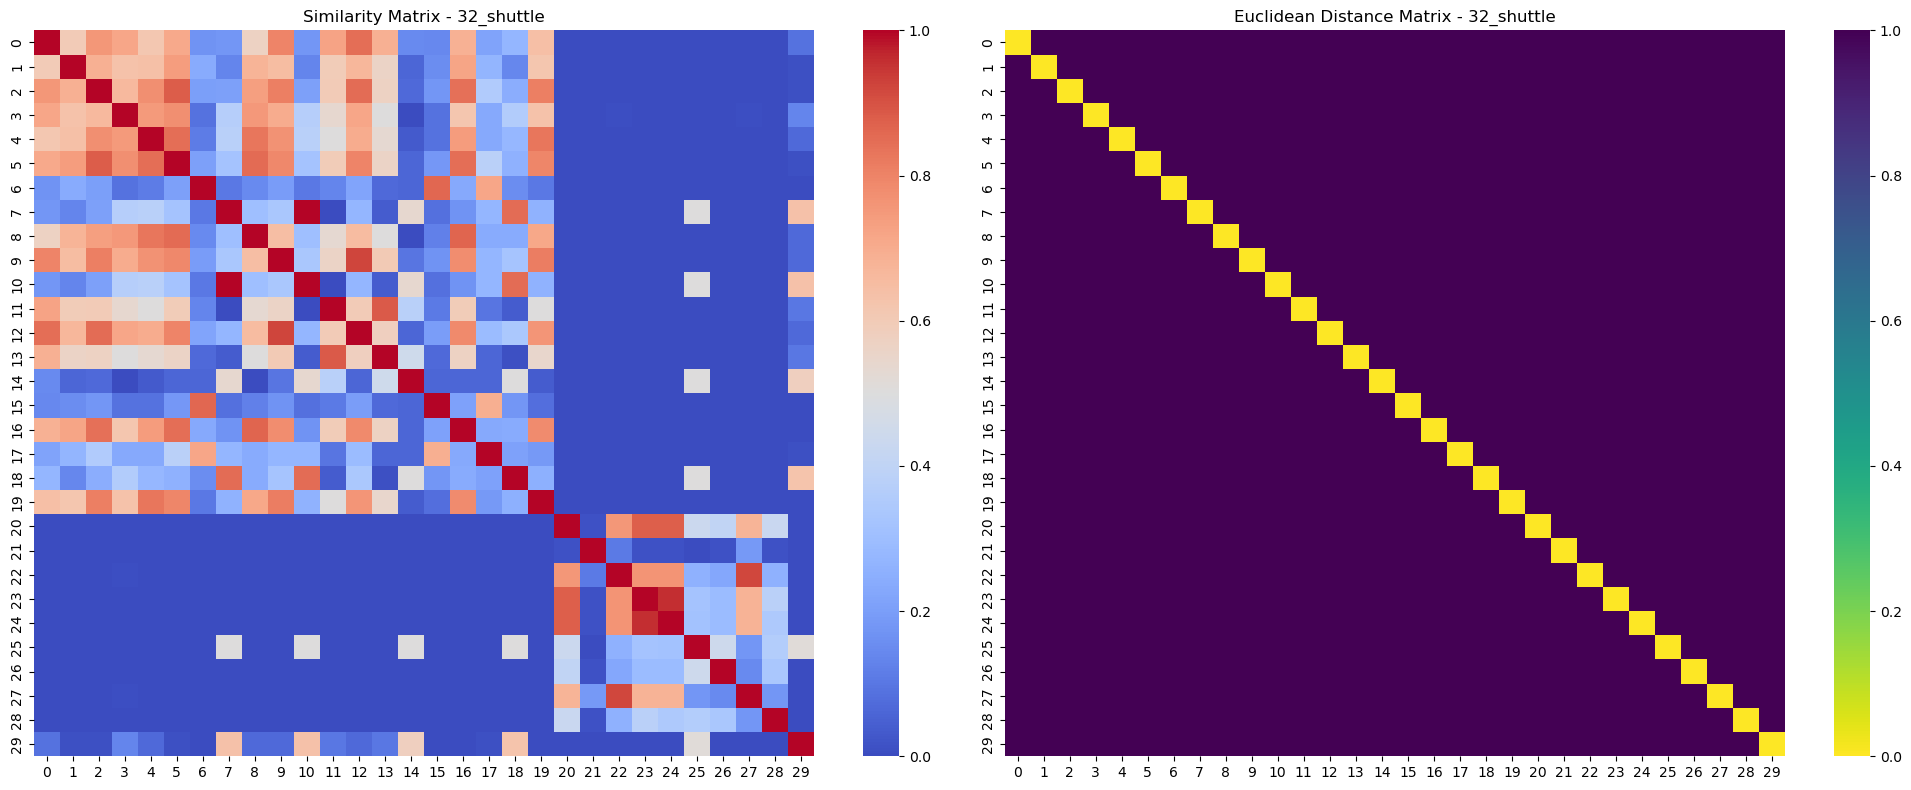

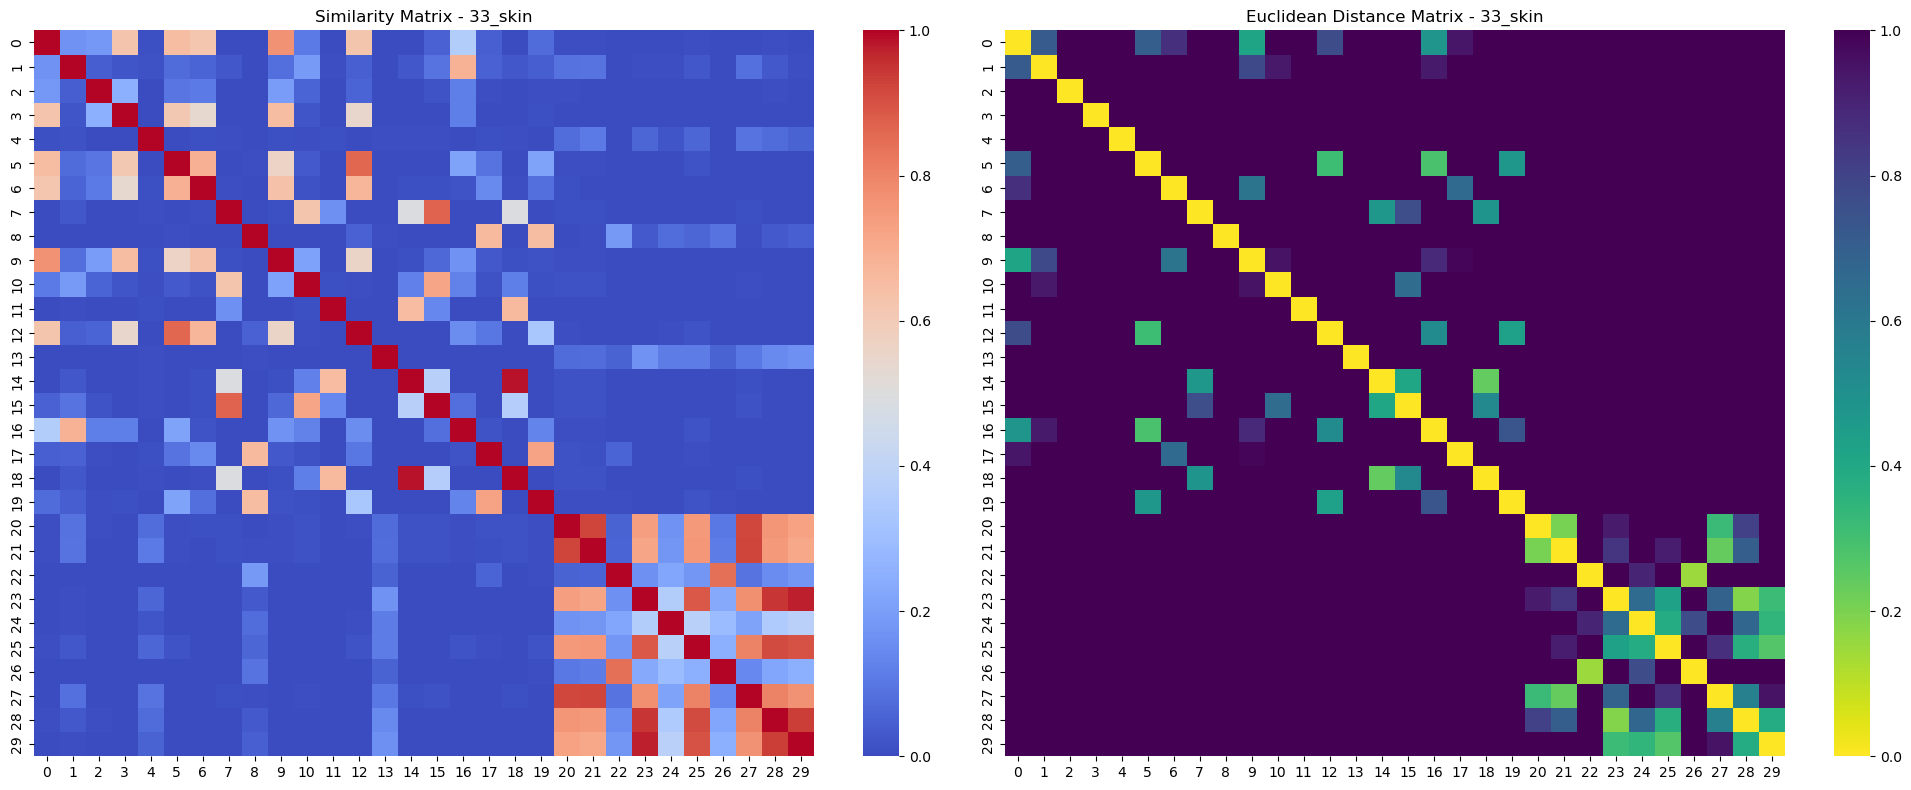

In [446]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_similarity_and_distance(similarity_matrix, distance_matrix, dataset_name):
  
    fig, axes = plt.subplots(1, 2, figsize=(20, 8)) 
    distance_matrix=cap_values(distance_matrix)
    similarity_matrix=cap_values(similarity_matrix)

    sns.heatmap(similarity_matrix, cmap='coolwarm', annot=False, ax=axes[0])
    axes[0].set_title(f'Similarity Matrix - {dataset_name}')

    sns.heatmap(distance_matrix, cmap='viridis_r', annot=False, ax=axes[1])
    axes[1].set_title(f'Euclidean Distance Matrix - {dataset_name}')

    plt.tight_layout()
    pdf_filename = f"{dataset_name}_similarity_distance_matrices.pdf"
    plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')

    # Show the plots
    plt.show()

# Loop through datasets and generate plots
for dataset_name in datasets:
    plot_similarity_and_distance(results[dataset_name]['similarity_matrix'], 
                                 results[dataset_name]['distance_matrix'], 
                                 dataset_name)

/var/folders/cw/5n__wtss1mn3kzz7j7fm7wfh0000gn/T/ipykernel_13700/3599338910.py:31: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.

/var/folders/cw/5n__wtss1mn3kzz7j7fm7wfh0000gn/T/ipykernel_13700/3599338910.py:32: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



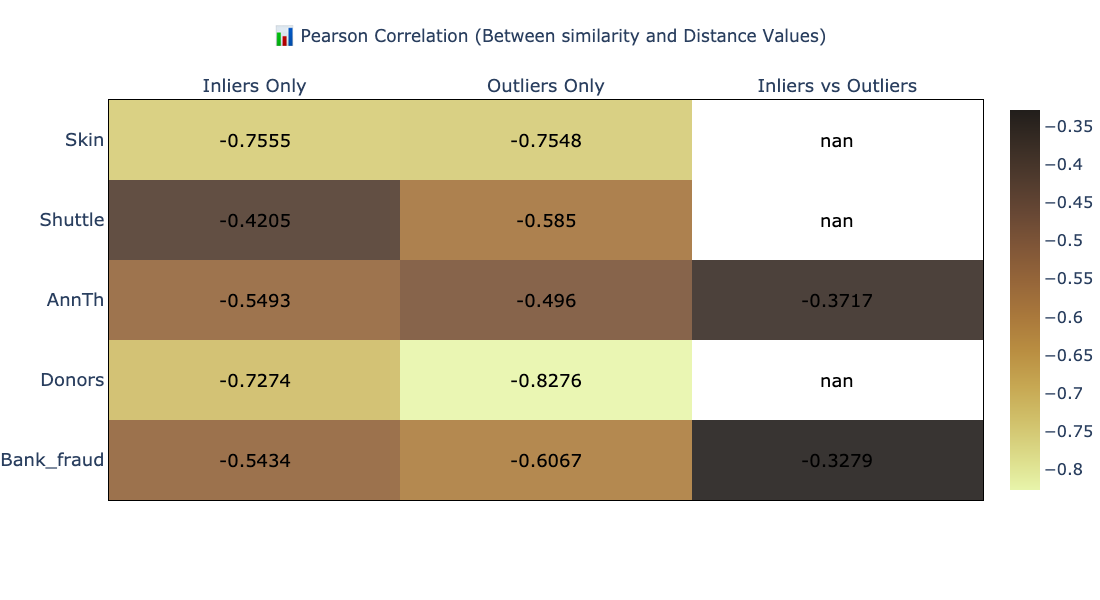

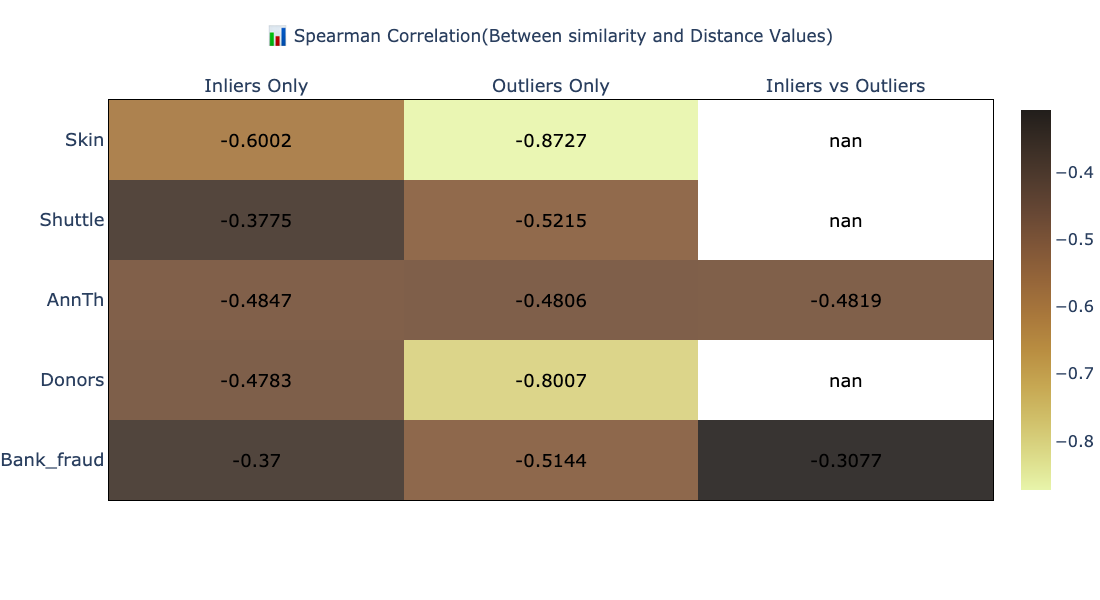

In [448]:
import numpy as np
import plotly.graph_objects as go
from scipy.stats import spearmanr, pearsonr
from tabulate import tabulate
from functools import reduce
from itertools import product
from IPython.display import Image

# List of datasets
datasets = ["Bank_fraud","11_donors", "2_annthyroid", "32_shuttle", "33_skin"]
dataset_abbreviations = ["Bank_fraud","Donors",  "AnnTh",  "Shuttle", "Skin"]

# Storage for correlation values
pearson_values = []
spearman_values = []

def compare_similarity_distance_by_group(similarity_matrix, distance_matrix, dataset_name):
    
    # Extract different regions
    inlier_similarity = similarity_matrix[:20, :20].flatten()  # Inliers only
    inlier_distance = distance_matrix[:20, :20].flatten()

    outlier_similarity = similarity_matrix[20:30, 20:30].flatten()  # Outliers only
    outlier_distance = distance_matrix[20:30, 20:30].flatten()

    cross_similarity = similarity_matrix[:20, 20:30].flatten()  # Inliers vs Outliers
    cross_distance = distance_matrix[:20, 20:30].flatten()

    # Compute correlation function
    def compute_correlations(similarity_values, distance_values):
        pearson_corr, _ = pearsonr(similarity_values, distance_values)
        spearman_corr, _ = spearmanr(similarity_values, distance_values)
        return pearson_corr, spearman_corr

    # Compute correlations for each case
    inlier_pearson, inlier_spearman = compute_correlations(inlier_similarity, inlier_distance)
    outlier_pearson, outlier_spearman = compute_correlations(outlier_similarity, outlier_distance)
    cross_pearson, cross_spearman = compute_correlations(cross_similarity, cross_distance)

    # Store results for visualization
    pearson_values.append([inlier_pearson, outlier_pearson, cross_pearson])
    spearman_values.append([inlier_spearman, outlier_spearman, cross_spearman])

    # Print table
    table_data = [
        ["Inliers Only", f"{inlier_pearson:.4f}", f"{inlier_spearman:.4f}"],
        ["Outliers Only", f"{outlier_pearson:.4f}", f"{outlier_spearman:.4f}"],
        ["Inliers vs Outliers", f"{cross_pearson:.4f}", f"{cross_spearman:.4f}"]
    ]
    #print(f"\n📊 Correlation Results - {dataset_name}")
    #print(tabulate(table_data, headers=["Category", "Pearson Correlation", "Spearman Correlation"], tablefmt="grid"))

# Run function for all datasets
for dataset_name in datasets:
    compare_similarity_distance_by_group(results[dataset_name]['similarity_matrix'], 
                                         results[dataset_name]['distance_matrix'], 
                                         dataset_name)

# Correlation categories (x-axis)
categories = ['Inliers Only', 'Outliers Only', 'Inliers vs Outliers']

def get_anno_text(z_value):
    annotations = []
    a, b = len(z_value), len(z_value[0])
    flat_z = reduce(lambda x, y: x + y, z_value)
    coords = product(range(a), range(b))
    for pos, elem in zip(coords, flat_z):
        annotations.append({'font': {'color': 'black'},
                            'showarrow': False,
                            'text': str(round(elem, 4)),  # Round for better readability
                            'x': pos[1],
                            'y': pos[0],
                            'font.size': 18})
    return annotations

# Function to generate heatmap figures
def create_heatmap(correlation_values, title, filename):
    fig = go.Figure(data=go.Heatmap(
        z=correlation_values,
        x=categories,  # Categories on x-axis
        y=dataset_abbreviations ,  # Datasets on y-axis
        hoverongaps=True,
        colorscale='turbid',  # Change colormap if needed
        opacity=0.9,
        colorbar=dict(tickfont=dict(size=16))
    ))

    fig.update_layout(
        title={'text': title, 'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'},
        plot_bgcolor='rgba(0,0,0,0)',
        annotations=get_anno_text(correlation_values),
        width=1100,
        height=600,
        xaxis={'side': 'top'},
        margin=dict(l=0, r=100, t=100, b=100)
    )

    fig.update_xaxes(tickfont=dict(size=18), linewidth=1, linecolor='black', mirror=True)
    fig.update_yaxes(tickfont=dict(size=18), linewidth=1, linecolor='black', mirror=True)

    fig.write_image(filename, engine="kaleido")
    fig.show()
    return Image(filename)

# Generate Pearson and Spearman heatmaps
pearson_image = create_heatmap(pearson_values, "📊 Pearson Correlation (Between similarity and Distance Values) ", "pearson_heatmap.png")
spearman_image = create_heatmap(spearman_values, "📊 Spearman Correlation(Between similarity and Distance Values)", "spearman_heatmap.png")

# Display images
from IPython.display import display, Image  
display(Image(filename="pearson_heatmap.png"))  
display(Image(filename="spearman_heatmap.png")) 

In [449]:
import numpy as np
from scipy.stats import spearmanr, pearsonr
from tabulate import tabulate  # For structured table formatting

def compare_similarity_distance_by_group(similarity_matrix, distance_matrix, dataset_name):
    # Extract different regions
    inlier_similarity = similarity_matrix[:20, :20].flatten()  # Inliers only
    inlier_distance = distance_matrix[:20, :20].flatten()

    outlier_similarity = similarity_matrix[20:30, 20:30].flatten()  # Outliers only
    outlier_distance = distance_matrix[20:30, 20:30].flatten()

    cross_similarity = similarity_matrix[:20, 20:30].flatten()  # Inliers vs Outliers
    cross_distance = distance_matrix[:20, 20:30].flatten()

    # Compute correlation function
    def compute_correlations(similarity_values, distance_values):
        pearson_corr, _ = pearsonr(similarity_values, distance_values)
        spearman_corr, _ = spearmanr(similarity_values, distance_values)
        return pearson_corr, spearman_corr

    # Compute correlations for each case
    inlier_pearson, inlier_spearman = compute_correlations(inlier_similarity, inlier_distance)
    outlier_pearson, outlier_spearman = compute_correlations(outlier_similarity, outlier_distance)
    cross_pearson, cross_spearman = compute_correlations(cross_similarity, cross_distance)

    # Prepare table data
    table_data = [
        ["Inliers Only", f"{inlier_pearson:.4f}", f"{inlier_spearman:.4f}"],
        ["Outliers Only", f"{outlier_pearson:.4f}", f"{outlier_spearman:.4f}"],
        ["Inliers vs Outliers", f"{cross_pearson:.4f}", f"{cross_spearman:.4f}"]
    ]

    # Print formatted table
    print(f"\n📊 Correlation Results - {dataset_name}")
    #print(tabulate(table_data, headers=["Category", "Pearson Correlation", "Spearman Correlation"], tablefmt="grid"))

    # Combined Interpretation
    print("\n📝 Summary of Correlations:")
    def interpret_correlations(pearson_corr, spearman_corr, label):
        if pearson_corr < -0.7 and spearman_corr < -0.7:
            print(f"✅ {label}: Strong negative correlation in both measures → Reliable  relationship.")
        elif pearson_corr < -0.7 and spearman_corr > -0.7:
            print(f"🔸 {label}: Pearson strong, Spearman weaker → Linear relationship but not rank-consistent.")
        elif pearson_corr > -0.7 and spearman_corr < -0.7:
            print(f"🔹 {label}: Spearman strong, Pearson weaker → General trend exists but not strictly linear.")
        elif pearson_corr > -0.3 and spearman_corr > -0.3:
            print(f"⚠️ {label}: Weak correlation → No strong link between similarity and distance.")
        else:
            print(f"❗ {label}: Moderate correlation → Some relationship, but not perfectly structured.")

    # Interpret results for each category
    interpret_correlations(inlier_pearson, inlier_spearman, "Inliers Only")
    interpret_correlations(outlier_pearson, outlier_spearman, "Outliers Only")
    interpret_correlations(cross_pearson, cross_spearman, "Inliers vs Outliers")

# Example usage:
for dataset_name in datasets:
    compare_similarity_distance_by_group(results[dataset_name]['similarity_matrix'], 
                                         results[dataset_name]['distance_matrix'], 
                                         dataset_name)


📊 Correlation Results - Bank_fraud

📝 Summary of Correlations:
❗ Inliers Only: Moderate correlation → Some relationship, but not perfectly structured.
❗ Outliers Only: Moderate correlation → Some relationship, but not perfectly structured.
❗ Inliers vs Outliers: Moderate correlation → Some relationship, but not perfectly structured.

📊 Correlation Results - 11_donors

📝 Summary of Correlations:
🔸 Inliers Only: Pearson strong, Spearman weaker → Linear relationship but not rank-consistent.
✅ Outliers Only: Strong negative correlation in both measures → Reliable  relationship.
❗ Inliers vs Outliers: Moderate correlation → Some relationship, but not perfectly structured.

📊 Correlation Results - 2_annthyroid

📝 Summary of Correlations:
❗ Inliers Only: Moderate correlation → Some relationship, but not perfectly structured.
❗ Outliers Only: Moderate correlation → Some relationship, but not perfectly structured.
❗ Inliers vs Outliers: Moderate correlation → Some relationship, but not perfect

/var/folders/cw/5n__wtss1mn3kzz7j7fm7wfh0000gn/T/ipykernel_13700/1428619550.py:18: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.

/var/folders/cw/5n__wtss1mn3kzz7j7fm7wfh0000gn/T/ipykernel_13700/1428619550.py:19: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



In [450]:
import pandas as pd
def display_similarity_dataframe(dataset_name):
    if dataset_name not in results:
        print(f"Dataset '{dataset_name}' not found in results.")
        return
    
    similarity_matrix = results[dataset_name]['similarity_matrix']
    
    # Convert NumPy array to Pandas DataFrame
    similarity_df = pd.DataFrame(similarity_matrix)

    print(f"Similarity DataFrame for {dataset_name}:")
    display(similarity_df.iloc[:10, :10])  # Show the first 10 rows and columns

for i in datasets[:2]:
    display_similarity_dataframe(i)

Similarity DataFrame for Bank_fraud:


,0,1,2,3,4,5,6,7,8,9
0,1.00,0.10,0.10,0.20,0.163265,0.18,0.08,0.06,0.26,0.02
1,0.10,1.00,0.18,0.18,0.142857,0.38,0.24,0.12,0.16,0.10
2,0.10,0.18,1.00,0.26,0.408163,0.18,0.16,0.16,0.16,0.08
3,0.20,0.18,0.26,1.00,0.244898,0.18,0.12,0.10,0.06,0.08
4,0.18,0.16,0.42,0.26,1.000000,0.16,0.16,0.14,0.20,0.04
5,0.18,0.38,0.18,0.18,0.142857,1.00,0.42,0.16,0.34,0.06
6,0.08,0.24,0.16,0.12,0.142857,0.42,1.00,0.22,0.34,0.06
7,0.06,0.12,0.16,0.10,0.122449,0.16,0.22,1.00,0.10,0.10
8,0.26,0.16,0.16,0.06,0.183673,0.34,0.34,0.10,1.00,0.08
9,0.02,0.10,0.08,0.08,0.020408,0.06,0.06,0.10,0.08,1.00


Similarity DataFrame for 11_donors:


,0,1,2,3,4,5,6,7,8,9
0,1.000000,0.000000,0.000000,0.000270,0.000000,0.000000,0.000110,0.000130,0.002240,0.000041
1,0.000000,1.000000,0.547953,0.000124,0.645237,0.645151,0.000000,0.000030,0.000183,0.000030
2,0.000000,0.547953,1.000000,0.000000,0.595327,0.539067,0.000030,0.000000,0.000000,0.000000
3,0.000270,0.000124,0.000000,1.000000,0.000000,0.000000,0.000000,0.000186,0.768751,0.000910
4,0.000000,0.645237,0.595327,0.000000,1.000000,0.943651,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.645151,0.539067,0.000000,0.943651,1.000000,0.000000,0.000000,0.000000,0.000000
6,0.000110,0.000000,0.000030,0.000000,0.000000,0.000000,1.000000,0.001936,0.000000,0.547316
7,0.000130,0.000030,0.000000,0.000186,0.000000,0.000000,0.001936,1.000000,0.000213,0.050166
8,0.002240,0.000183,0.000000,0.768751,0.000000,0.000000,0.000000,0.000213,1.000000,0.000936
9,0.000041,0.000030,0.000000,0.000910,0.000000,0.000000,0.547316,0.050166,0.000936,1.000000


## Step 6: Save Model and Results

In [452]:
#with open('proximity_learning_catboost.pkl', 'wb') as f:
    #pickle.dump(results, f)

# Label Propagation in Semi-Supervised Learning

## Introduction
Label Propagation is a powerful semi-supervised learning technique that spreads label information from a small set of labeled data points to a larger set of unlabeled data. It is based on the idea that similar data points should have similar labels. This is particularly useful in scenarios where obtaining labeled data is expensive or time-consuming, such as fraud detection, anomaly detection, and medical diagnosis.

## How Label Propagation Works
Label Propagation works by constructing a graph where:
1. **Nodes represent data points** – both labeled and unlabeled.
2. **Edges represent similarity** – weights between nodes indicate how similar they are.
3. **Labels are propagated iteratively** – starting from labeled nodes, labels spread to nearby unlabeled nodes based on similarity.

### Steps of Label Propagation:
1. **Construct a similarity graph:** Compute a similarity matrix where edges indicate similarity between data points.
2. **Initialize labels:** Assign known labels to labeled nodes and leave unlabeled nodes empty.
3. **Iterative propagation:** Update the label of each unlabeled node based on the labels of its neighbors.
4. **Convergence:** Repeat the process until the labels stabilize.

## Advantages of Label Propagation
- **Reduces labeling costs:** Only a small portion of the dataset needs to be labeled.
- **Captures underlying data structure:** Uses relationships between data points to make better predictions.
- **Works well in many applications:** Used in fraud detection, credit risk assessment, image classification, and more.

## Example Use Case: Fraud Detection
In financial fraud detection, label propagation helps in semi-supervised anomaly detection. A small set of known fraudulent transactions can be used to propagate fraud labels to suspicious transactions based on transaction similarities, customer behavior, or spending patterns.

## Conclusion
Label Propagation is an efficient method for leveraging unlabeled data to improve classification performance. By utilizing the natural structure of data, it enhances model accuracy while minimizing the need for manual labeling.


# Ensure imports are only run once
if "np" not in globals():
    import numpy as np
    import matplotlib.pyplot as plt
    import ipywidgets as widgets
    from ipywidgets import interact
    from sklearn.decomposition import PCA
    from catboost import CatBoostClassifier
    from mpl_toolkits.mplot3d import Axes3D
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score  # ✅ FIXED IMPORTS

datasets = [
    "11_donors", "22_magic.gamma", "24_mnist", "27_PageBlocks",
    "2_annthyroid", "30_satellite", "32_shuttle", "33_skin",
    "6_cardio", "7_Cardiotocography"
]

def process_dataset(dataset_name, sample_size=3000, n_components=3, iterations=500,
                    depth=8, learning_rate=0.05, elev=30, azim=120):
    print(f"\nProcessing dataset: {dataset_name}")

    try:
        # Load dataset
        X, y = load_dataset(dataset_name)

        # Ensure sample_size does not exceed dataset size
        sample_size = min(sample_size, len(X))
        indices = np.random.choice(len(X), sample_size, replace=False)
        X, y = X[indices], y[indices]

        # Normalize features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Split data into train and test sets
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

        # Train CatBoost model
        model = CatBoostClassifier(
            iterations=iterations, depth=depth, learning_rate=learning_rate, 
            loss_function='Logloss', verbose=0
        )
        model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50, verbose=100)

        # Get predictions
        y_pred = model.predict(X_test)

        # Compute AUC score
        auc_score = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]) * 100
        print(f"AUC Score: {auc_score:.2f}%")

        # Apply PCA for 3D visualization
        pca = PCA(n_components=n_components)
        X_pca = pca.fit_transform(X_test)

        # Categorize points based on predictions
        categories = np.zeros(len(y_test))
        categories[(y_test == 0) & (y_pred == 0)] = 0  # Normal → Normal
        categories[(y_test == 0) & (y_pred == 1)] = 1  # Normal → Anomalous
        categories[(y_test == 1) & (y_pred == 0)] = 2  # Anomalous → Normal
        categories[(y_test == 1) & (y_pred == 1)] = 3  # Anomalous → Anomalous

        # Define colors and labels
        colors = {0: 'darkblue', 1: 'darkolivegreen', 2: 'cyan', 3: 'darkgoldenrod'}
        labels = {0: "Normal → Normal", 1: "Normal → Anomalous", 
                  2: "Anomalous → Normal", 3: "Anomalous → Anomalous"}

        # Plot 3D scatter
        fig = plt.figure(figsize=(16, 13))
        ax = fig.add_subplot(111, projection='3d')

        for cat in np.unique(categories):
            indices = np.where(categories == cat)
            ax.scatter(X_pca[indices, 0], X_pca[indices, 1], X_pca[indices, 2], 
                       color=colors[cat], label=labels[cat], alpha=1, marker='$☯$', s=150)

        ax.set_xlabel("PCA Component 1", fontsize=10, fontweight='bold', color='darkslategray')
        ax.set_ylabel("PCA Component 2", fontsize=10, fontweight='bold', color='darkslategray')
        ax.set_zlabel("PCA Component 3", fontsize=10, fontweight='bold', color='darkslategray')
        ax.set_title(f"3D Visualization - {dataset_name}", fontsize=14, fontweight='bold', color='darkred')
        ax.tick_params(axis='x', which='both', bottom=False, top=False)
        ax.tick_params(axis='y', which='both', left=False, right=False)
        ax.tick_params(axis='z', which='both', bottom=False, top=False)

        ax.view_init(elev=elev, azim=azim)
        ax.legend()

        plt.show()

    except Exception as e:
        print(f"⚠️ Error processing {dataset_name}: {e}")

# Interactive controls
interact(
    process_dataset, 
    dataset_name=widgets.Dropdown(options=datasets, description="Dataset", layout=widgets.Layout(width='700px')),
    sample_size=widgets.IntSlider(min=500, max=30000, step=500, value=3000, description="Sample Size", layout=widgets.Layout(width='700px')),
    n_components=widgets.IntSlider(min=2, max=7, step=1, value=3, description="PCA Components", layout=widgets.Layout(width='700px')),
    iterations=widgets.IntSlider(min=100, max=1000, step=100, value=500, description="Iterations", layout=widgets.Layout(width='700px')),
    depth=widgets.IntSlider(min=4, max=12, step=1, value=8, description="Depth", layout=widgets.Layout(width='700px')),
    learning_rate=widgets.FloatSlider(min=0.01, max=0.2, step=0.01, value=0.05, description="Learning Rate", layout=widgets.Layout(width='700px')),
    elev=widgets.IntSlider(min=0, max=90, step=5, value=30, description="Elevation", layout=widgets.Layout(width='700px')),
    azim=widgets.IntSlider(min=0, max=360, step=10, value=120, description="Azimuth", layout=widgets.Layout(width='700px'))
)

In [663]:
# Ensure imports are only run once
if "np" not in globals():
    import numpy as np
    import matplotlib.pyplot as plt
    import ipywidgets as widgets
    from ipywidgets import interact
    from catboost import CatBoostClassifier
    from mpl_toolkits.mplot3d import Axes3D
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
    from sklearn.metrics import roc_auc_score

datasets = ["Bank_fraud", "11_donors", "22_magic.gamma", "24_mnist",
            "2_annthyroid", "30_satellite", "32_shuttle", "33_skin"]

def process_dataset(dataset_name, sample_size=20000, iterations=500,
                    depth=8, learning_rate=0.05, elev=30, azim=120):
    print(f"\nProcessing dataset: {dataset_name}")

    try:
        if dataset_name == "Bank_fraud":
            X_numeric = X1.select_dtypes(include=['number'])  # Keep only numeric columns
            X, y = X_numeric.to_numpy(), y1.to_numpy()  # Convert to NumPy arrays
            feature_names = X_numeric.columns  # Store feature names
        else:
            X, y = load_dataset(dataset_name)
            feature_names = [f"Feature_{i}" for i in range(X.shape[1])]

        # Ensure sample_size does not exceed dataset size
        sample_size = min(sample_size, len(X))

        # Stratified sampling
        sss = StratifiedShuffleSplit(n_splits=1, test_size=(1 - sample_size / len(X)), random_state=42)
        train_index, _ = next(sss.split(X, y))
        X, y = X[train_index], y[train_index]

        # Normalize features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Split data into train and test sets (stratified)
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.4, stratify=y, random_state=42)

        # Train CatBoost model
        model = CatBoostClassifier(
            iterations=iterations, depth=depth, learning_rate=learning_rate, 
            loss_function='Logloss', verbose=0
        )
        model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50, verbose=100)

        # Compute AUC score
        y_pred_probs = model.predict_proba(X_test)[:, 1]  
        auc_score = roc_auc_score(y_test, y_pred_probs) * 100
        print(f"AUC Score: {auc_score:.2f}%")  # Print the AUC Score

        # Compute feature importance
        feature_importances = model.get_feature_importance()
        sorted_indices = np.argsort(feature_importances)[::-1]  # Sort in descending order
        top_features = sorted_indices[:3]  # Select top 3

        # Get feature names
        feature_rank1, feature_rank2, feature_rank3 = feature_names[top_features[0]], feature_names[top_features[1]], feature_names[top_features[2]]
        print(f"Top 3 Features: {feature_rank1}, {feature_rank2}, {feature_rank3}")

        # Extract top 3 feature columns for visualization
        X_top3 = X_test[:, top_features]

        # Identify top 10 most anomalous points
        top_anomalous_indices = np.argsort(y_pred_probs)[-10:]

        # Create a colormap for probabilities
        cmap = plt.cm.Spectral_r
        norm = plt.Normalize(vmin=0, vmax=1)
        colors = cmap(norm(y_pred_probs))

        # Plot 3D scatter
        fig = plt.figure(figsize=(16, 13))
        ax = fig.add_subplot(111, projection='3d')

        # Plot all points with colormap
        ax.scatter(X_top3[:, 0], X_top3[:, 1], X_top3[:, 2], 
                   c=colors, alpha=1, marker='$☯$', s=80)

        # Highlight top 10 anomalous points with red
        ax.scatter(X_top3[top_anomalous_indices, 0], X_top3[top_anomalous_indices, 1], X_top3[top_anomalous_indices, 2], 
                   marker='$☯$', color='red', label="Top 10 Anomalies", edgecolors='black', s=400)

        ax.set_xlabel(f"{feature_rank1} (Feature_Rank1)", fontsize=10, fontweight='bold', color='darkslategray')
        ax.set_ylabel(f"{feature_rank2} (Feature_Rank2)", fontsize=10, fontweight='bold', color='darkslategray')
        ax.set_zlabel(f"{feature_rank3} (Feature_Rank3)", fontsize=10, fontweight='bold', color='darkslategray')
        ax.set_title(f"Normal vs Anomaly visualization - {dataset_name}", fontsize=14, fontweight='bold', color='darkred')

        ax.view_init(elev=elev, azim=azim)
        ax.legend()

        plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="Anomaly Probability")
        plt.show()

    except Exception as e:
        print(f"⚠️ Error processing {dataset_name}: {e}")

# Interactive controls
widget = interact(
    process_dataset, 
    dataset_name=widgets.Dropdown(options=datasets, description="Dataset", layout=widgets.Layout(width='700px')),
    sample_size=widgets.IntSlider(min=500, max=6000, step=500, value=6000, description="Sample Size", layout=widgets.Layout(width='700px')),
    iterations=widgets.IntSlider(min=100, max=1000, step=100, value=500, description="Iterations", layout=widgets.Layout(width='700px')),
    depth=widgets.IntSlider(min=4, max=12, step=1, value=8, description="Depth", layout=widgets.Layout(width='700px')),
    learning_rate=widgets.FloatSlider(min=0.01, max=0.2, step=0.01, value=0.05, description="Learning Rate", layout=widgets.Layout(width='700px')),
    elev=widgets.IntSlider(min=0, max=90, step=5, value=30, description="Elevation", layout=widgets.Layout(width='700px')),
    azim=widgets.IntSlider(min=0, max=360, step=10, value=120, description="Azimuth", layout=widgets.Layout(width='700px'))
)

interactive(children=(Dropdown(description='Dataset', layout=Layout(width='700px'), options=('Bank_fraud', '11…